**CONNECTING TO DRIVE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**IMPORTING LIBRARIES**

In [ ]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torch import nn, optim
import matplotlib.pyplot as plt

**PREPROCESSING THE DATA: LOADING AND TRANSFORMING**

In [ ]:
from PIL import Image, ImageFile
import os
# Allow loading truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models

# Setting the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Defining transforms
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # <- ResNet expects 3 channels
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

#Loading datasets
train_data = torchvision.datasets.ImageFolder('/content/drive/MyDrive/bone_fracture/train', transform=transform)
test_data = torchvision.datasets.ImageFolder('/content/drive/MyDrive/bone_fracture/test', transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=16, shuffle=False)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


**LOADING AND ADAPTING THE PRE-TRAINED RESNET-18 MODEL**

In [ ]:
# Loading and freezing model so that the entire model is not trainable
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False

# Replacing last layer (original has 1000 layers)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# Unfreezing last layer
for param in model.fc.parameters():
    param.requires_grad = True

# Moving model to device
model = model.to(device)

# Defining optimizer
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


**DEFINING THE TRAINING AND EVALUATION FUNCTIONS**

In [ ]:
def train(model, dataloader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for i, (inputs, labels) in enumerate(dataloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / len(dataloader.dataset)
    print('Finished Training')
    return avg_loss, accuracy



def evaluate(model, dataloader, criterion):
    model.eval()  # Evaluation mode
    total_loss = 0.0
    correct = 0
    all_preds, all_labels = [], []

    with torch.no_grad():  # No gradient tracking
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / len(dataloader.dataset)

    #print(f'Average Loss on Test Set: {avg_loss:.4f}')
    #print(f'Accuracy on Test Set: {accuracy:.2f}%')

    return avg_loss, accuracy, all_preds, all_labels


**DEFINING THE LOOP FOR TRAINING AND EVALUATING THE MODEL ON THE TEST DATA**

In [ ]:
# ==== Training Loop ====
epochs = 20
train_loss, test_loss = [], []
train_acc, test_acc = [], []

for epoch in range(epochs):
    print(f"\n[Epoch {epoch+1}/{epochs}]")
    t_loss, t_acc = train(model, train_loader, optimizer, criterion)
    v_loss, v_acc, y_pred, y_true = evaluate(model, test_loader, criterion)

    train_loss.append(t_loss)
    test_loss.append(v_loss)
    train_acc.append(t_acc)
    test_acc.append(v_acc)

    print(f"Train Loss: {t_loss:.4f}, Train Acc: {t_acc:.2f}%")
    print(f"Test  Loss: {v_loss:.4f}, Test  Acc: {v_acc:.2f}%")
    print("-" * 50)

print("TRAINING COMPLETE")




[Epoch 1/20]
Finished Training
Train Loss: 0.4526, Train Acc: 79.12%
Test  Loss: 0.3918, Test  Acc: 81.78%
--------------------------------------------------

[Epoch 2/20]
Finished Training
Train Loss: 0.3385, Train Acc: 85.92%
Test  Loss: 0.3437, Test  Acc: 86.24%
--------------------------------------------------

[Epoch 3/20]
Finished Training
Train Loss: 0.3036, Train Acc: 87.75%
Test  Loss: 0.3526, Test  Acc: 87.02%
--------------------------------------------------

[Epoch 4/20]
Finished Training
Train Loss: 0.2823, Train Acc: 88.55%
Test  Loss: 0.3478, Test  Acc: 81.01%
--------------------------------------------------

[Epoch 5/20]
Finished Training
Train Loss: 0.2625, Train Acc: 89.45%
Test  Loss: 0.2896, Test  Acc: 87.79%
--------------------------------------------------

[Epoch 6/20]
Finished Training
Train Loss: 0.2556, Train Acc: 89.27%
Test  Loss: 0.2778, Test  Acc: 88.57%
--------------------------------------------------

[Epoch 7/20]
Finished Training
Train Loss: 0.

**SAVING THE MODEL; PLOTTING TEST&TRAIN LOSS CURVES AND TEST&TRAIN ACCURACY CURVES**

Model saved as fracture_cnn_model.pth


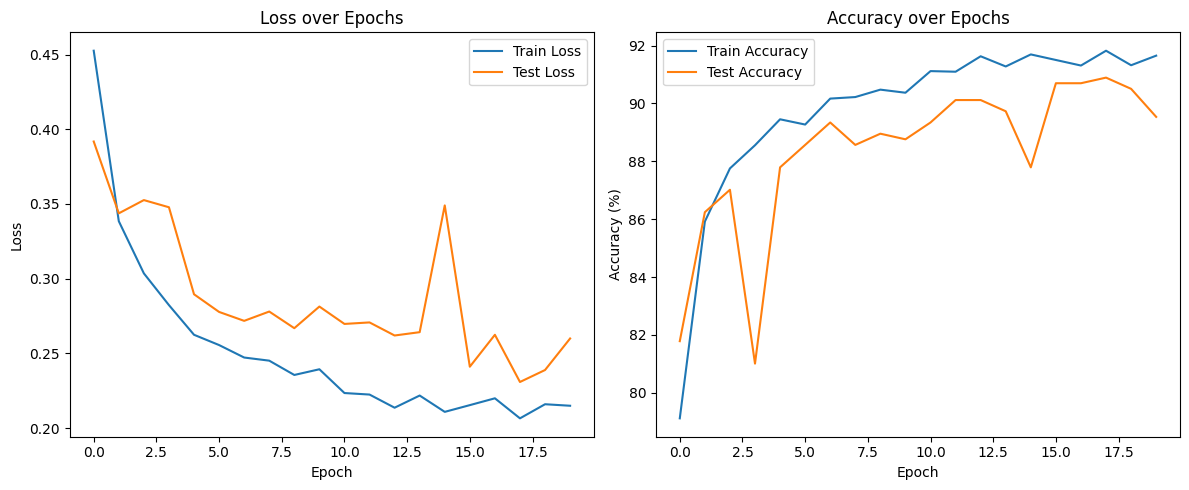

In [ ]:
# ==== Save Model ====
torch.save(model.state_dict(), "fracture_cnn_model.pth")
print("Model saved as fracture_cnn_model.pth")

# ==== Plot Loss ====
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# ==== Plot Accuracy ====
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy over Epochs")
plt.legend()
plt.tight_layout()
plt.show()


**CLASSIFYING AND DISPLAYING 50 IMAGES FROM THE VALIDATION DATA USING  PRE-TRAINED RESNET-18**

Computation device: cpu


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/17-rotated2-rotated1.jpg


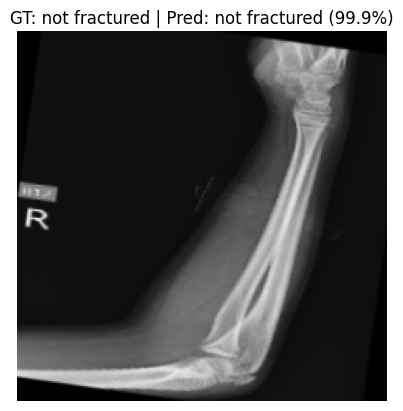


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/41-rotated3-rotated1-rotated2.jpg


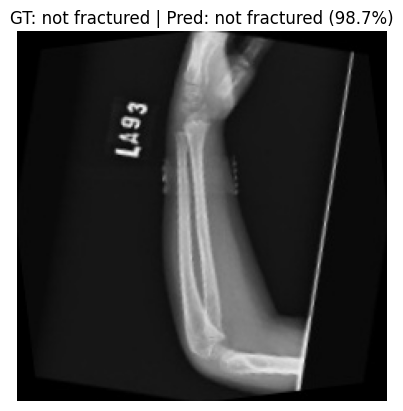


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/15-rotated2-rotated1-rotated2-rotated1.jpg


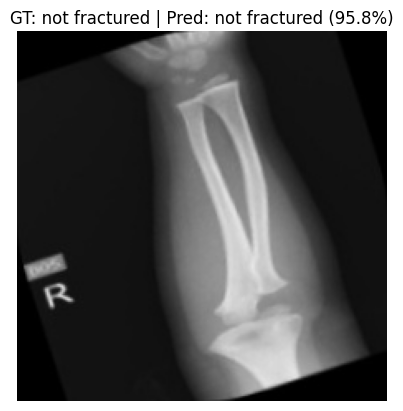


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/IMG0000182.jpg


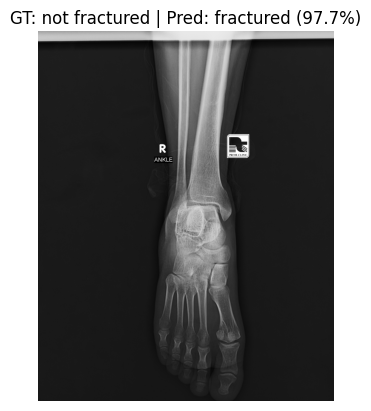


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/22-rotated2-rotated1-rotated2-rotated1.jpg


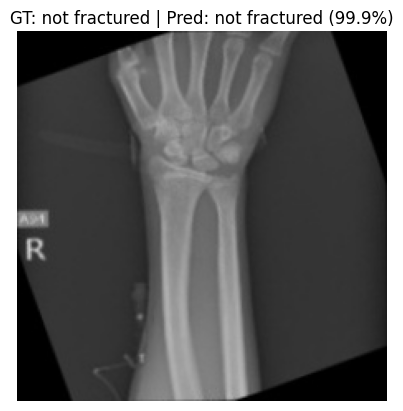


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/36-rotated2-rotated2-rotated1.jpg


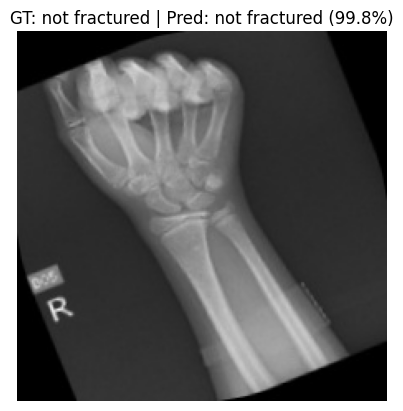


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/2.png


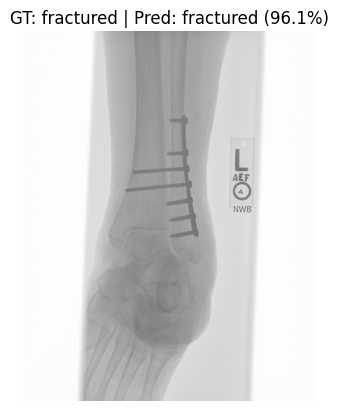


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/IMG0004341.jpg


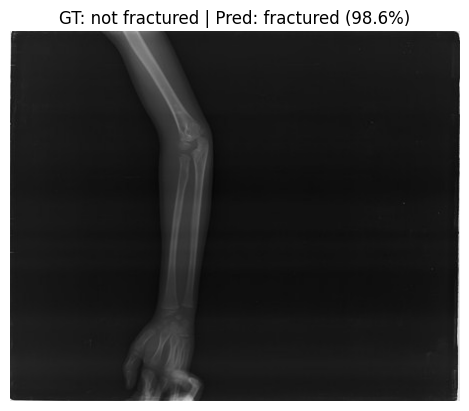


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/3-rotated3-rotated3-rotated1.jpg


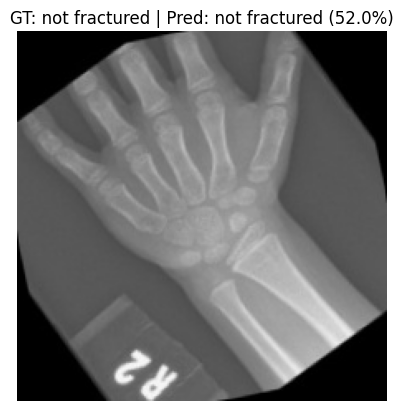


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/3-rotated2-rotated1-rotated3-rotated1.jpg


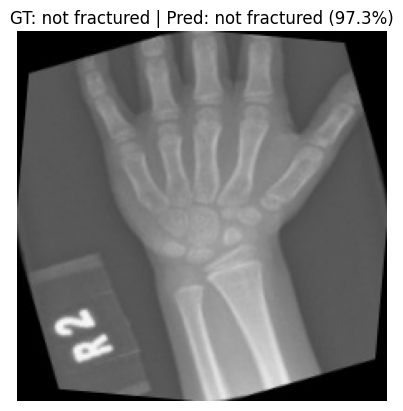


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/3-rotated3-rotated1-rotated3.jpg


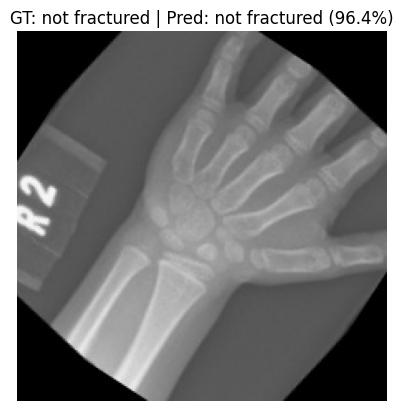


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/9-rotated1-rotated2-rotated1.jpg


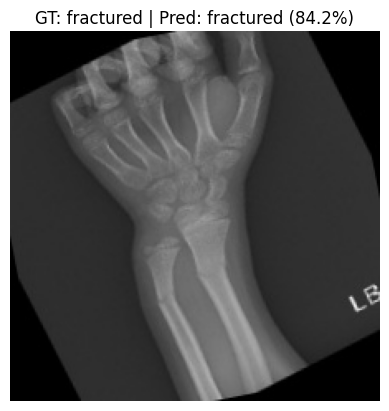


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/20-rotated2-rotated3-rotated3-rotated1.jpg


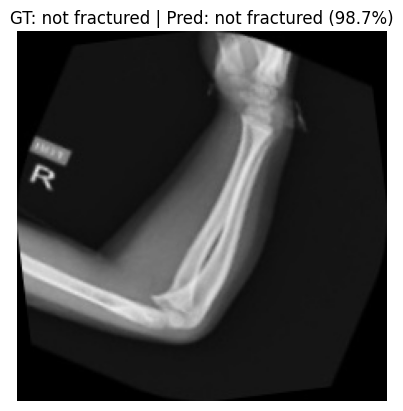


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/23-rotated3-rotated3-rotated3.jpg


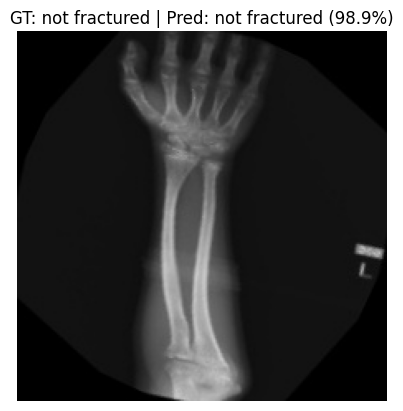


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/25-rotated3-rotated1-rotated2-rotated1.jpg


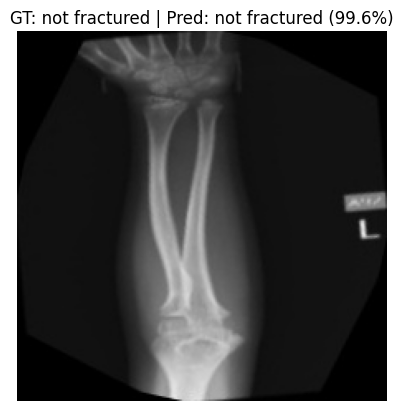


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/0015.png


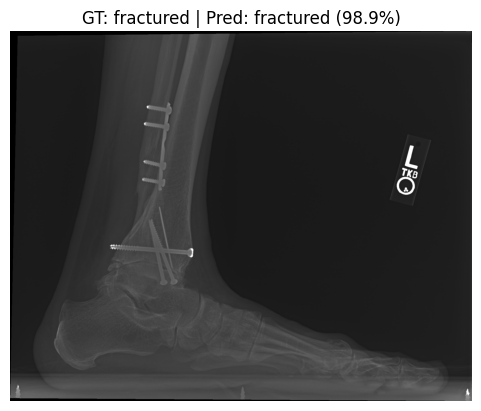


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/31-rotated2-rotated1.jpg


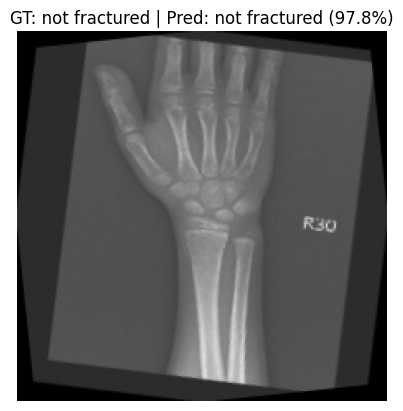


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/images3.jpg


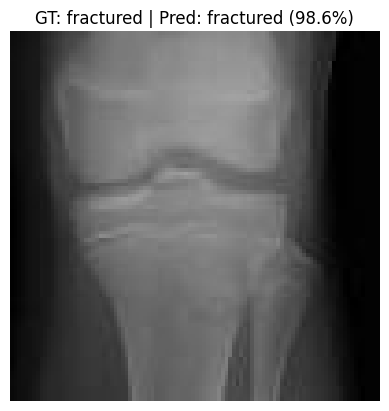


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/4-rotated2-rotated1.jpg


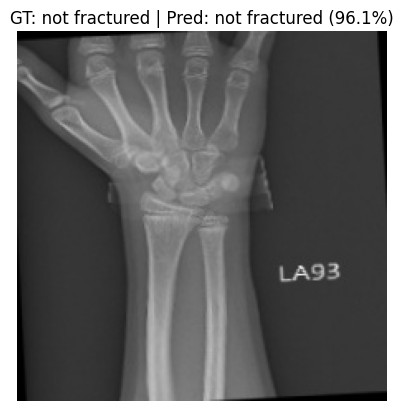


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/gr1_lrg.jpg


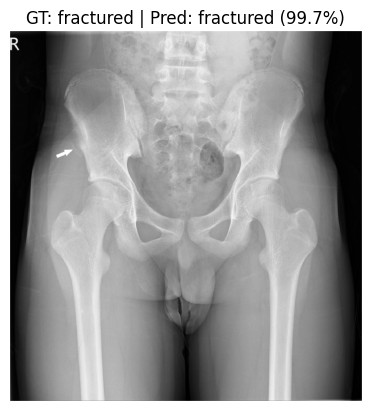


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/79.jpg


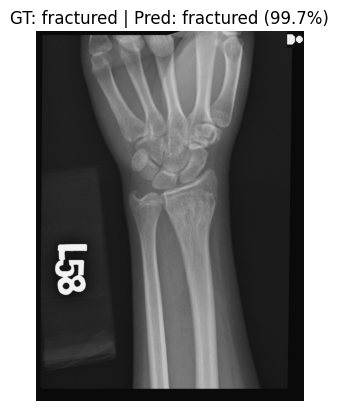


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/IMG0002476.jpg


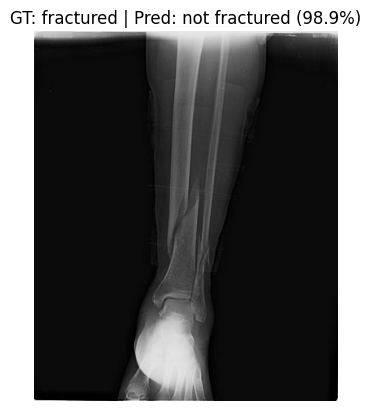


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/IMG0002514.jpg


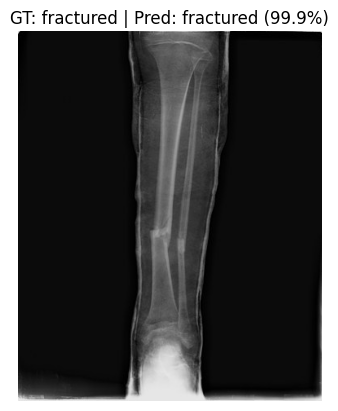


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/gr15.jpg


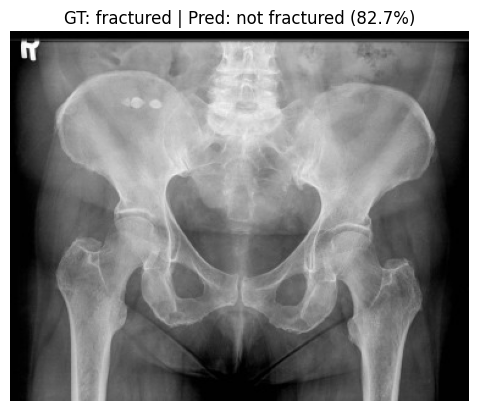


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/20-rotated1-rotated2-rotated2.jpg


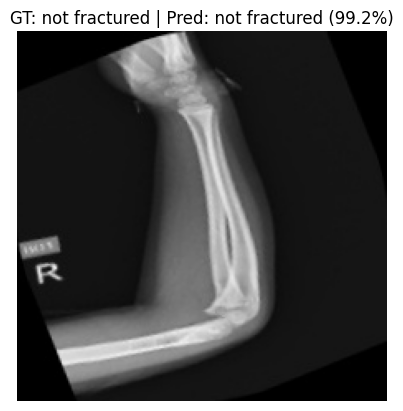


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/images2.jpg


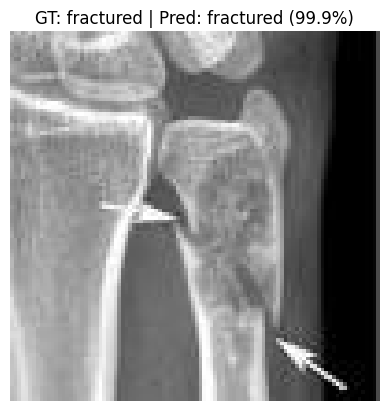


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/50-rotated3-rotated3-rotated2.jpg


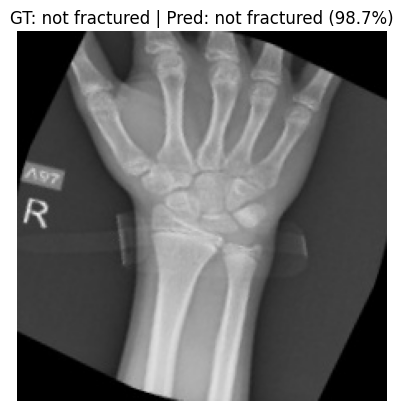


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/6.png


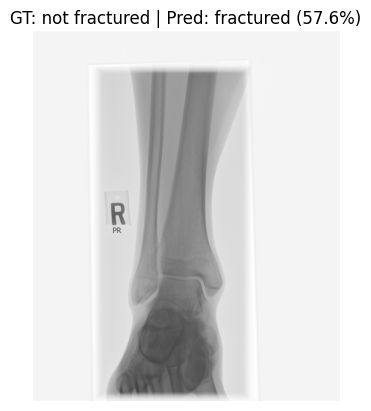


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/25-rotated3-rotated1-rotated3.jpg


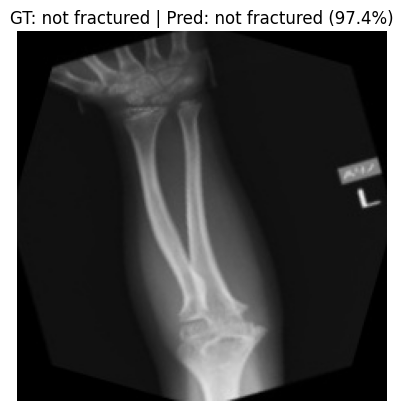


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/37-rotated2-rotated3-rotated3.jpg


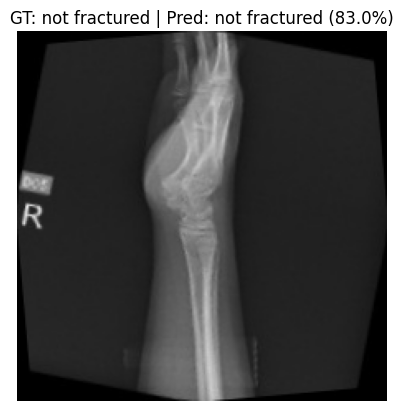


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/88-rotated1-rotated3.jpg


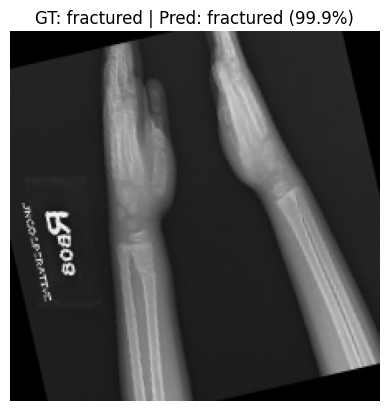


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/10-rotated3-rotated3-rotated1.jpg


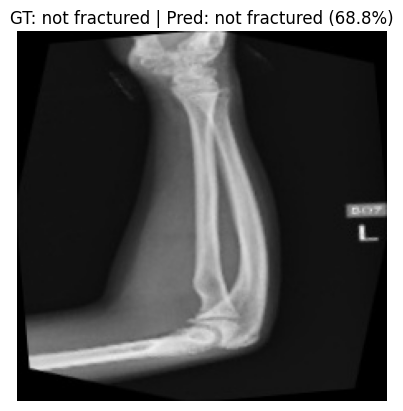


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/84-rotated2.jpg


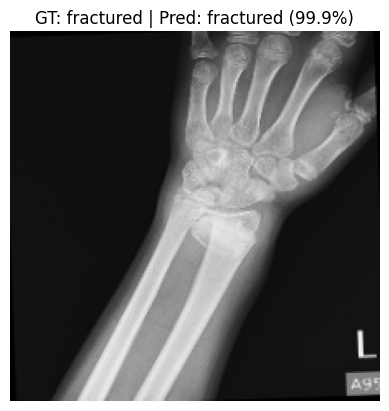


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/8-rotated3-rotated2-rotated1.jpg


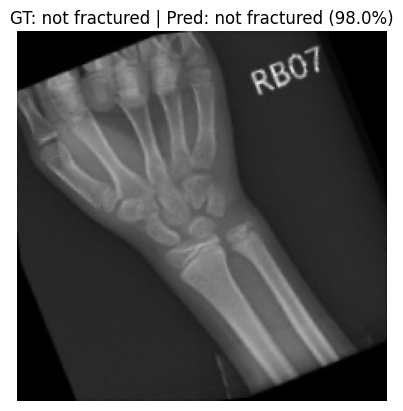


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/32-rotated2-rotated2.jpg


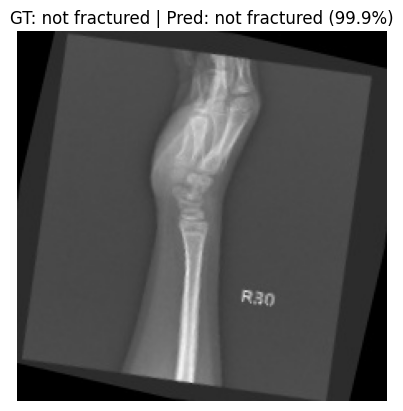


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/39-rotated1-rotated2.jpg


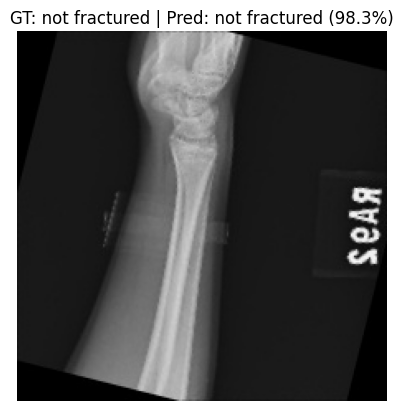


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/82-rotated3.jpg


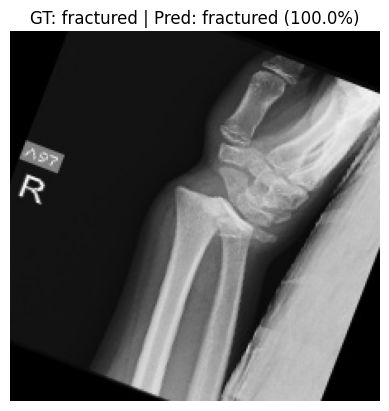


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/IMG0002400.jpg


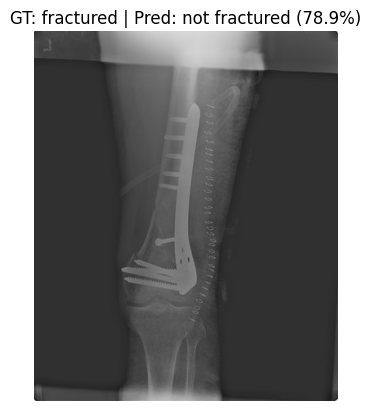


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/IMG0000185.jpg


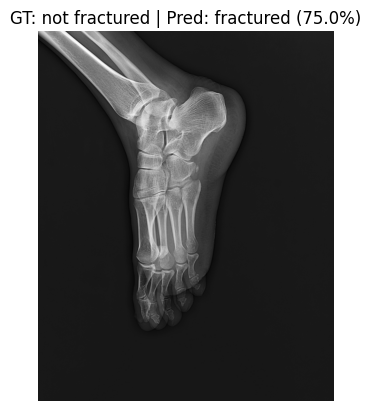


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/17-rotated1-rotated2-rotated2-rotated1.jpg


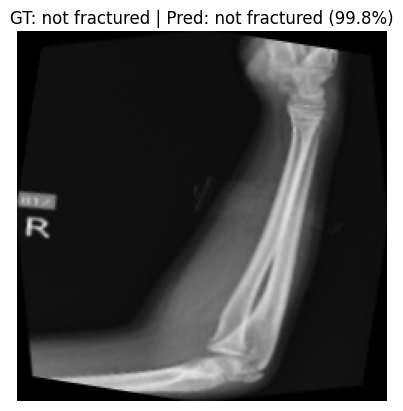


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/4-rotated2.jpg


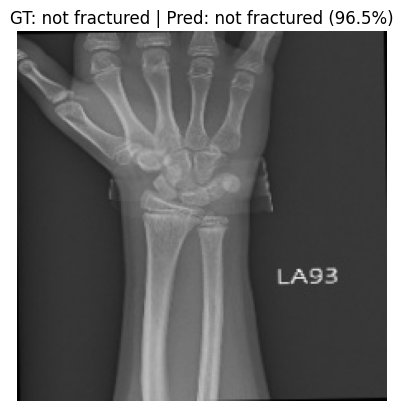


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/1b.jpg


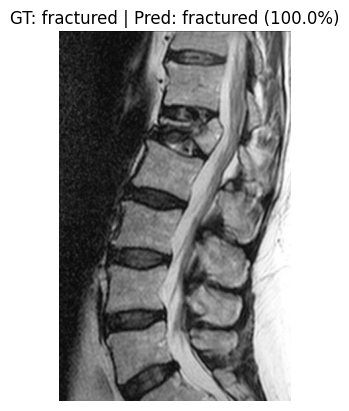


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/88-rotated2-rotated2-rotated2.jpg


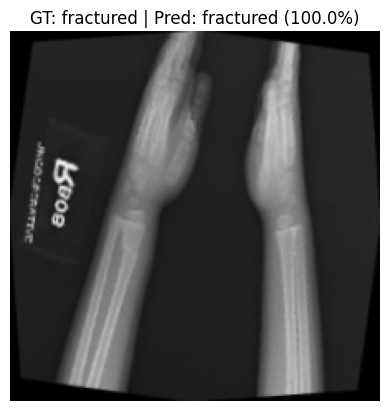


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/11.png


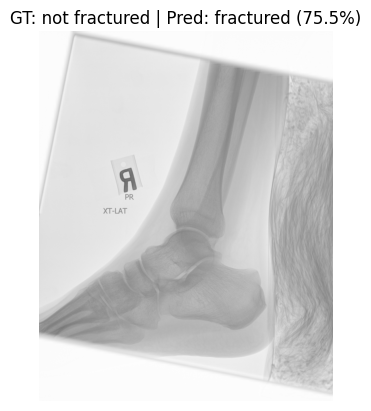


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/16-rotated3-rotated3-rotated1.jpg


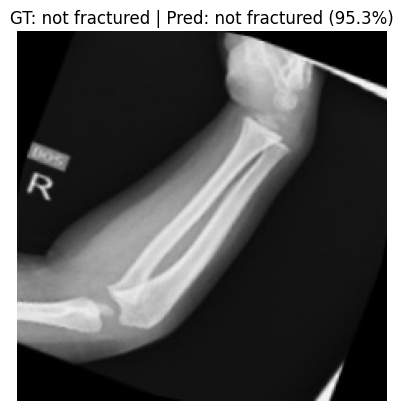


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/33-rotated3-rotated2-rotated3-rotated1.jpg


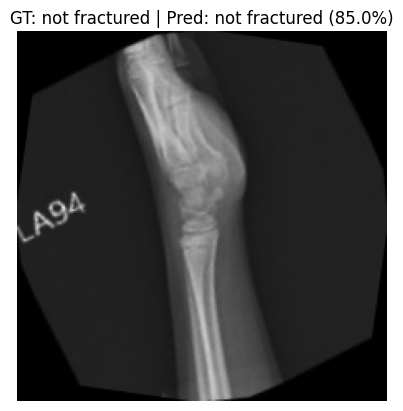


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/79-rotated3-rotated3-rotated3.jpg


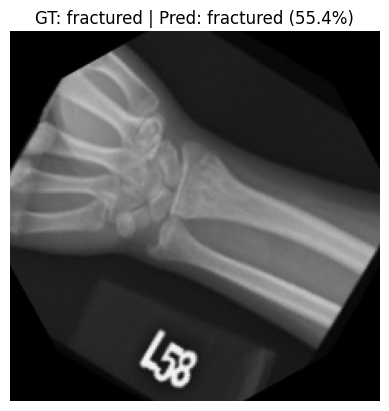


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/85-rotated3-rotated3-rotated3.jpg


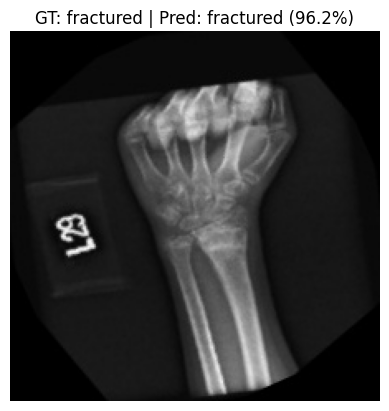


Processing: /content/drive/MyDrive/bone_fracture/val/not fractured/00755.png


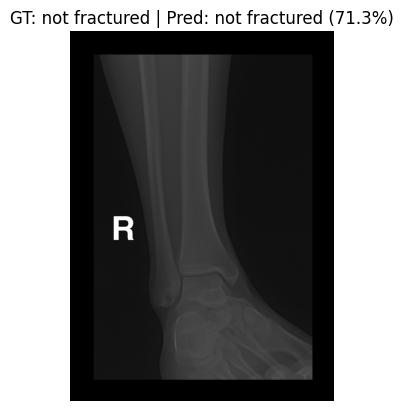


Processing: /content/drive/MyDrive/bone_fracture/val/fractured/97-rotated3-rotated3-rotated3.jpg


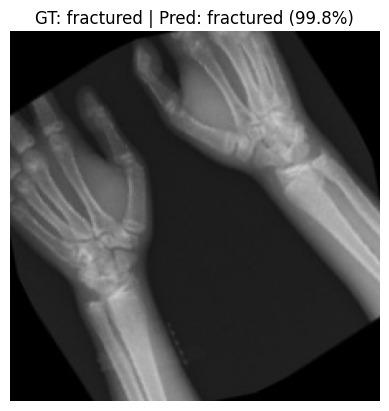

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F


# Model is in evaluation mode
model.eval()

# Setting the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Computation device: {device}\n')

# Class labels
labels = ['fractured', 'not fractured']

# Defining transforms
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # <- ResNet expects 3 channels
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Validation directory path
val_dir = '/content/drive/MyDrive/bone_fracture/val'


# Collecting all image paths and their true labels
all_images = []
for label_idx, label_name in enumerate(labels):
    class_dir = os.path.join(val_dir, label_name)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('png', 'jpg', 'jpeg','bmp'))]
    for image_filename in image_files:
        image_path = os.path.join(class_dir, image_filename)
        all_images.append((image_path, label_name))

# Randomly sampling 50 images
sampled_images = random.sample(all_images, 50)

# Predicting and displaying each sampled image
for image_path, gt_label in sampled_images:
    print(f"\nProcessing: {image_path}")
    try:
        image = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Error loading image: {e}")
        continue

    # Applying transform and sending to device
    input_tensor = transform(image).unsqueeze(0).to(device)


    with torch.no_grad():
        output = model(input_tensor)
        probabilities = F.softmax(output, dim=1)
        pred_idx = probabilities.argmax(dim=1).item()
        pred_label = labels[pred_idx]
        confidence = probabilities[0, pred_idx].item() * 100  # Converting to percentage (confidence interval)

    # Displaying the result
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"GT: {gt_label} | Pred: {pred_label} ({confidence:.1f}%)")
    plt.show()


In [ ]:
!pip install scikit-learn


**PLOTTING THE ROC CURVE FOR THE PRE-TRAINED RESNET-18 USING TEST DATA**

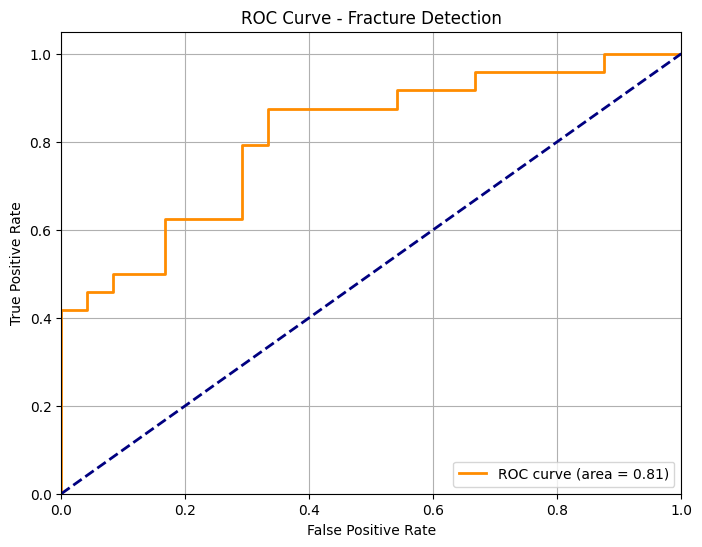

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Evaluating the model
model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        # Getting probability for class 1 (Fractured)
        probs = F.softmax(outputs, dim=1)[:, 1]

        y_true.extend(labels.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())

# Computing ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plotting ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Fracture Detection')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
